In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [22]:
summary_dir = Path("local_conda_test_7252126_results/summary")
# summary_dir = Path("local_venv_test_7252126_results/summary")
mufluxes = np.load(summary_dir / "combined_mufluxes.npy")
psfc = np.load(summary_dir / "combined_psfc.npy", allow_pickle=True) # not working yet
times = np.load(summary_dir / "combined_times.npy", allow_pickle=True)

In [23]:
mufluxes.shape
# (x, y, z) means x time-points, array of angles of length z, array of fluxes of length z

(5, 2, 15)

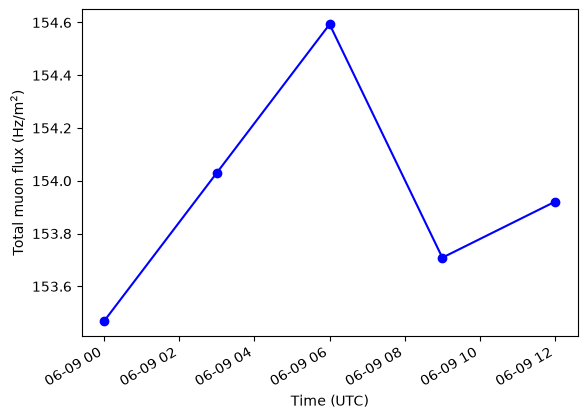

In [24]:
muflux_sum_over_ang = np.sum(mufluxes, axis=2)[:,1]

fig, ax_flux = plt.subplots()
# ax_psfc = ax_flux.twinx()

ax_flux.plot(times, muflux_sum_over_ang, marker='o', color="blue", label="Flux")
ax_flux.set_xlabel('Time (UTC)')
ax_flux.set_ylabel('Total muon flux (Hz/m$^2$)')
# ax_flux.legend(loc="upper left")

# ax_psfc.plot(times, psfc, marker='o', color="red", label="PSFC")
# ax_psfc.set_ylabel('PSFC [hPa]')
# ax_psfc.set_xlabel('Time (UTC)')
# ax_psfc.legend(loc="upper right")

fig.autofmt_xdate()
plt.show()

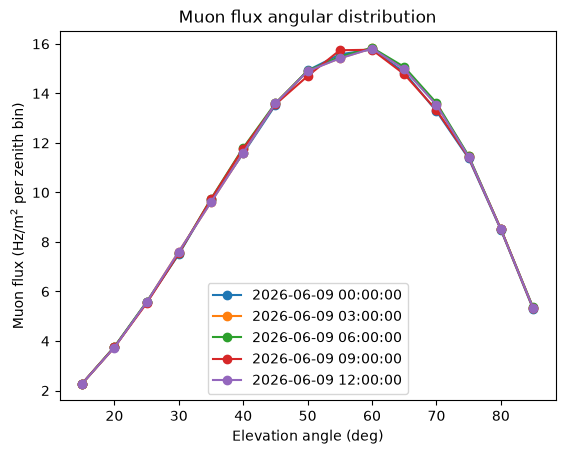

In [25]:
for i, muflux_t in enumerate(mufluxes):
    angles, flux = muflux_t[0], muflux_t[1]

    plt.plot(angles, flux, marker='o', label=times[i])
plt.xlabel('Elevation angle (deg)')
plt.ylabel('Muon flux (Hz/m$^2$ per zenith bin)')
plt.legend()
plt.title(f'Muon flux angular distribution')
plt.show()